# 09. 発展トピック — 境界値問題・SDE・制御・ODE の学習

| 層 | セクション |
|---|---|
| Applied | 1. 境界値問題 〜 4. ODE の学習 |
| Advanced | 5. Advanced Notes |

これまでは初期値問題(時間を前へ進める)が中心でした。本章はその先の 4 つの発展テーマを、
`ode_book.advanced` の小さな参照実装で体験します。

In [1]:
# Shared setup. Make the book package importable whether or not it is pip-installed,
# then fix the random seed and tidy NumPy printing.
import sys
from pathlib import Path

try:
    import ode_book  # noqa: F401
except ModuleNotFoundError:
    for _base in (Path.cwd(), *Path.cwd().parents):
        if (_base / "src" / "ode_book").is_dir():
            sys.path.insert(0, str(_base / "src"))
            break

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
np.set_printoptions(precision=4, suppress=True)

In [2]:
from ode_book import advanced, solvers, systems, plotting
import numpy as np

## 1. 境界値問題 (BVP) と射撃法

初期値問題は「出発点と速度」を与えますが、**境界値問題** は「両端の値」を与えます
(例: 棒の両端の温度、梁の両端の固定)。両端条件 $y(a)=\alpha,\ y(b)=\beta$ を満たす解は、
初期スロープ $s=y'(a)$ を未知数として「撃ち出しては当てる」**射撃法 (shooting)** で求まります。
例として $y''=6x,\ y(0)=0,\ y(1)=1$(厳密解 $y=x^3$)を解きます。

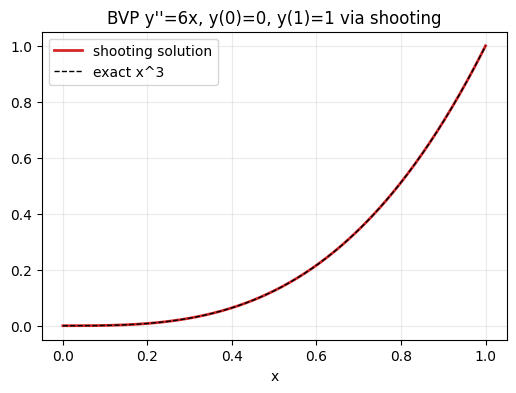

max |shooting - x^3| = 5.551115123125783e-16


In [3]:
# Shooting: tune the initial slope so the trajectory hits the far boundary.
x, y = advanced.shooting_bvp(lambda t, yy, yp: 6 * t, 0.0, 1.0, 0.0, 1.0, n=400)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x, y, color="#d62728", lw=2, label="shooting solution")
ax.plot(x, x**3, "k--", lw=1, label="exact x^3")
ax.legend(); ax.grid(alpha=0.25); ax.set_xlabel("x")
ax.set_title("BVP y''=6x, y(0)=0, y(1)=1 via shooting")
plt.show()
print("max |shooting - x^3| =", float(np.max(np.abs(y - x**3))))

### 固有値問題 — 弦の振動モード

境界値問題の親戚が **固有値問題** $-y''=\lambda y,\ y(0)=y(L)=0$。解が存在するのは
$\lambda_n=(n\pi/L)^2$ のときだけで、対応する $\sin(n\pi x/L)$ が弦の **振動モード**(05/05 章の変数分離と同じ)。
離散化した作用素の固有値が解析値に一致することを確認します。

mode 1: numeric lambda =    9.870   exact (n pi)^2 =    9.870
mode 2: numeric lambda =   39.478   exact (n pi)^2 =   39.478
mode 3: numeric lambda =   88.825   exact (n pi)^2 =   88.826
mode 4: numeric lambda =  157.908   exact (n pi)^2 =  157.914


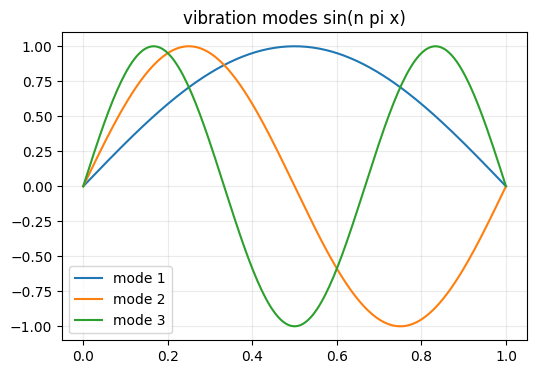

In [4]:
# Sturm-Liouville eigenvalues -y''=lam y, y(0)=y(1)=0: numeric vs (n pi)^2.
eig = advanced.sturm_liouville_eigenvalues(n_modes=4, length=1.0, n_grid=600)
for n, lam in enumerate(eig, 1):
    print(f"mode {n}: numeric lambda = {lam:8.3f}   exact (n pi)^2 = {(n * np.pi)**2:8.3f}")
xs = np.linspace(0, 1, 200)
fig, ax = plt.subplots(figsize=(6, 4))
for n in (1, 2, 3):
    ax.plot(xs, np.sin(n * np.pi * xs), label=f"mode {n}")
ax.legend(); ax.grid(alpha=0.25); ax.set_title("vibration modes sin(n pi x)")
plt.show()

## 2. 確率微分方程式 (SDE) — Euler-Maruyama

07 章で触れた Vasicek $dr=\kappa(\theta-r)dt+\sigma dW$ の **完全版** です。$\sigma\,dW$ はランダムな揺らぎ
(ブラウン運動)。**Euler-Maruyama 法** は Euler 法にノイズ項 $\sigma\sqrt{\Delta t}\,Z$ を足すだけ。
多数のパスの **平均は決定論的 ODE 解** に一致し、**分散は $\sigma^2/(2\kappa)$ に収束** します。

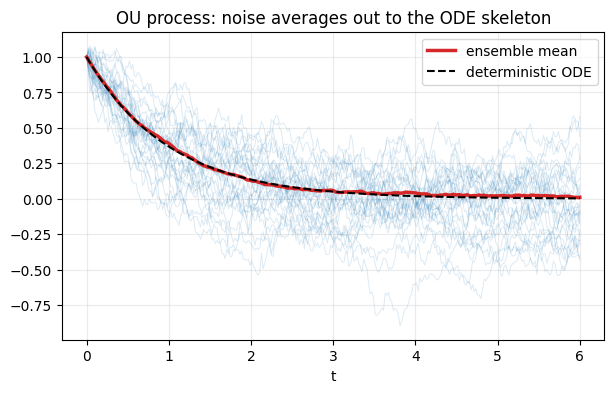

stationary std (theory sigma/sqrt(2 kappa)) = 0.2121  | empirical late-time std = 0.2167


In [5]:
# Ornstein-Uhlenbeck: many noisy paths; their mean is the deterministic ODE solution.
t = np.linspace(0, 6, 300)
kappa, theta, sigma, y0 = 1.0, 0.0, 0.3, 1.0
paths = advanced.ou_ensemble(kappa, theta, sigma, y0, t, n_paths=300, seed=1)
fig, ax = plt.subplots(figsize=(7, 4))
for p in paths[:30]:
    ax.plot(t, p, color="#1f77b4", alpha=0.15, lw=0.7)
ax.plot(t, paths.mean(0), color="#d62728", lw=2.5, label="ensemble mean")
ax.plot(t, theta + (y0 - theta) * np.exp(-kappa * t), "k--", lw=1.5, label="deterministic ODE")
ax.legend(); ax.grid(alpha=0.25); ax.set_xlabel("t")
ax.set_title("OU process: noise averages out to the ODE skeleton")
plt.show()
print("stationary std (theory sigma/sqrt(2 kappa)) =", round(sigma / np.sqrt(2 * kappa), 4),
      " | empirical late-time std =", round(float(paths[:, -1].std()), 4))

## 3. 制御 — フィードバックで安定化(LQR・極配置)

不安定・中立な系をフィードバック $u=-Kx$ で安定化します。台車 $\ddot{x}=u$(二重積分器)を例に:

- **極配置**: 閉ループ $A-BK$ の固有値(極)を指定した位置に置く。
- **LQR**: コスト $\int x^\top Q x + u^\top R u$ を最小化する $K$ を Riccati 方程式から求める(最適制御)。

pole placement K = [[6. 5.]]  -> poles [-2. -3.]
LQR            K = [[1.    1.732]]  -> closed-loop eig [-0.866+0.5j -0.866-0.5j]


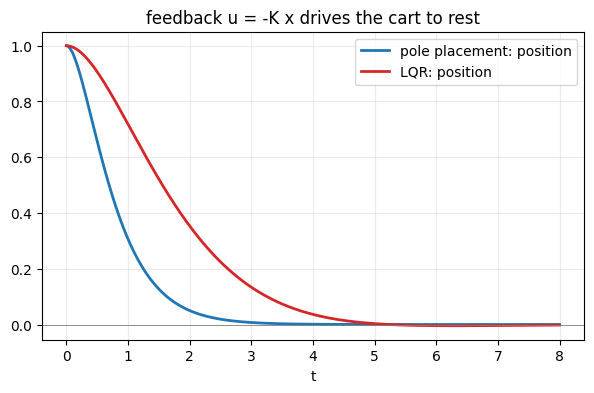

In [6]:
# Double integrator x'' = u. Stabilize with pole placement and with LQR.
A = np.array([[0.0, 1.0], [0.0, 0.0]])
B = np.array([[0.0], [1.0]])
K_pp, poles = advanced.place_poles(A, B, [-2.0, -3.0])
K_lqr, cl = advanced.lqr(A, B, Q=np.eye(2), R=[[1.0]])
print("pole placement K =", np.round(K_pp, 3), " -> poles", np.round(poles, 3))
print("LQR            K =", np.round(K_lqr, 3), " -> closed-loop eig", np.round(cl, 3))

t = np.linspace(0, 8, 400)
fig, ax = plt.subplots(figsize=(7, 4))
for K, name, col in [(K_pp, "pole placement", "#1f77b4"), (K_lqr, "LQR", "#d62728")]:
    Y = solvers.rk4(systems.linear_system(A - B @ K), [1.0, 0.0], t)
    ax.plot(t, Y[:, 0], color=col, lw=2, label=f"{name}: position")
ax.axhline(0, color="gray", lw=0.6); ax.legend(); ax.grid(alpha=0.25); ax.set_xlabel("t")
ax.set_title("feedback u = -K x drives the cart to rest")
plt.show()

## 4. ODE を「学習」する — Neural ODE の心臓部

05/07 章で触れた Neural ODE は、**データに合うように右辺 $f_\theta$ のパラメータを学習** します。
その核心は「**損失をソルバ越しに微分して勾配降下する**」こと。ここでは最も単純な線形場
$dx/dt=Ax$ の $A$ を、観測した軌道から **最小二乗で復元** します(本物の Neural ODE は $f_\theta$ を
小さなニューラルネットにし、随伴法で勾配を取るだけの違い)。

true A =
 [[-0.3  1. ]
 [-1.  -0.3]] 
fitted A =
 [[-0.3  1. ]
 [-1.  -0.3]]


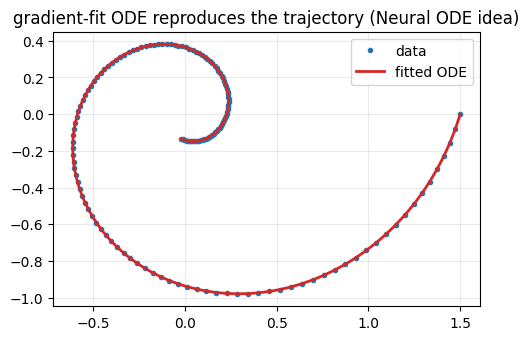

In [7]:
# "Train" an ODE: recover the matrix A of dx/dt = A x from an observed trajectory.
A_true = np.array([[-0.3, 1.0], [-1.0, -0.3]])  # stable spiral (unknown to the fitter)
t = np.linspace(0, 8, 150)
data = solvers.rk4(systems.linear_system(A_true), [1.5, 0.0], t)
A_fit = advanced.fit_linear_system(t, data)
pred = solvers.rk4(systems.linear_system(A_fit), data[0], t)
print("true A =\n", A_true, "\nfitted A =\n", np.round(A_fit, 3))
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.plot(data[:, 0], data[:, 1], "o", ms=3, color="#1f77b4", label="data")
ax.plot(pred[:, 0], pred[:, 1], color="#d62728", lw=2, label="fitted ODE")
ax.legend(); ax.grid(alpha=0.25); ax.set_aspect("equal")
ax.set_title("gradient-fit ODE reproduces the trajectory (Neural ODE idea)")
plt.show()

## Exercises

1. 射撃法で非線形 BVP $y''=y^2-x,\ y(0)=0,\ y(1)=1$ を解け(初期スロープの初期推定を変えて収束を見る)。
2. OU アンサンブルで、定常分散が $\sigma^2/(2\kappa)$ に近づくことを複数の $\kappa$ で確かめよ。
3. LQR の重み $R$ を大きく(制御コスト高)すると、ゲイン $K$ と収束速度がどう変わるか調べよ。
4. `fit_linear_system` に観測ノイズを加えたデータを与え、復元精度の劣化を見よ。

## Advanced Notes

- **射撃法の限界**: 不安定な IVP では撃ち出しが発散しやすい。安定なのは **有限差分法**(BVP を線形系に直接離散化)や `scipy.integrate.solve_bvp`。
- **Itô vs Stratonovich**: SDE の積分の定義は一通りではない。Euler-Maruyama は Itô 解釈。金融は Itô、物理は Stratonovich が多い。
- **可制御性**: 極配置・LQR が可能なのは系が **可制御**(controllability 行列がフルランク)なとき。二重積分器は可制御。
- **随伴法 (adjoint)**: Neural ODE は順方向の解と逆方向の随伴 ODE を解いて勾配を $O(1)$ メモリで得る。`torchdiffeq` が代表。